In [2]:
import sys
sys.path.append("..") # This is for the imports from adjacent folders to work
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200
#plt.rcParams.update({'font.size': 15})

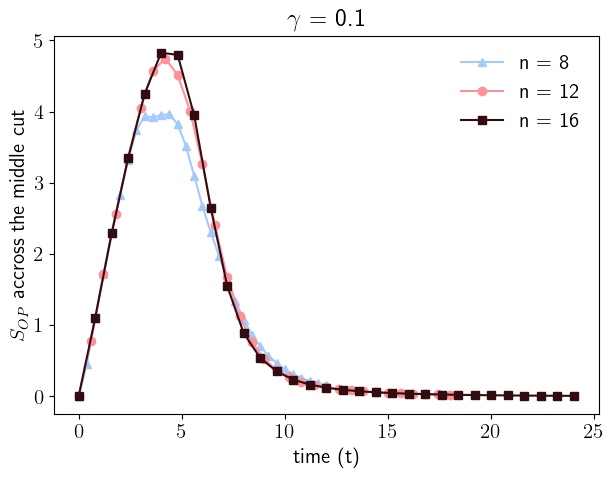

In [ ]:
sizes = [8, 12, 16]
colors = ["#a4cafd", "#fd9299", "#320c10"]
markers = ["^", "o", "s"]
gamma = 0.1
for (idx, n) in enumerate(sizes):
    mb = np.floor_divide(n, 2)
    tns = pd.read_csv(f'data_plots_ruben/open_n{n}_g0p100_g0p10_profile.csv', usecols=["t", "bond", "S_op_bond"])
    s = tns.loc[tns["bond"] == mb, "S_op_bond"].to_numpy()
    t = tns.loc[tns["bond"] == 1, "t"].to_numpy()
    plt.plot(t, s, marker = markers[idx], color = colors[idx], linestyle = "solid", label = f"n = {n}")

plt.ylabel("$S_{OP}$ accross the middle cut")
plt.xlabel("time (t)")
plt.legend(frameon = False)
plt.tight_layout()
plt.title(f"$\\gamma$ = {gamma}")
plt.savefig("[RUBEN]S_op_gamma_01.png", bbox_inches='tight', transparent = True)
plt.show()

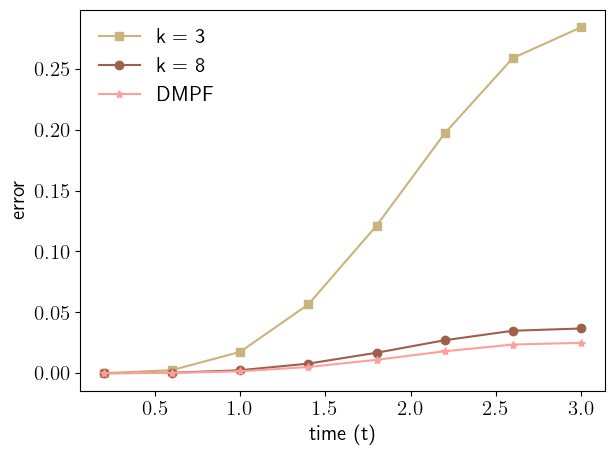

In [9]:
tns = pd.read_csv(f'data_plots_ruben/frobenius_results.csv')
tns

colors = ["#c9b47b", "#9f5f4a", "#ff9f9d"]
markers = ["s", 'o', '*']
labels = ['E_trot_k3', "E_trot_k8", "E_mpf"]
title = ["k = 3", "k = 8", "DMPF"]

time = tns["time"]
for (idx, l) in enumerate(labels):
    plt.plot(time, tns[l], color = colors[idx], linestyle = 'solid', marker = markers[idx], label = title[idx])

plt.xlabel("time (t)")
plt.ylabel("error")
# plt.yscale("log")
plt.legend(frameon = False)
plt.tight_layout()
plt.savefig("[RUBEN]trotter_error.png", bbox_inches='tight', transparent = True)
plt.show()

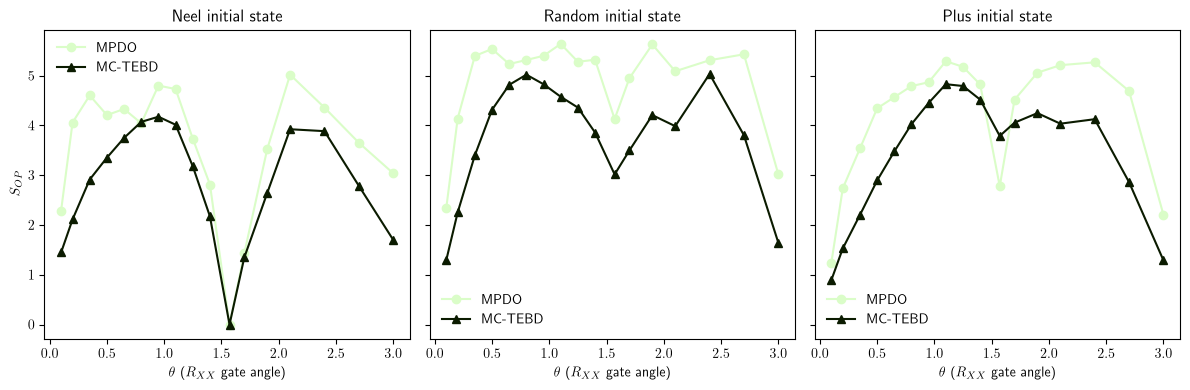

In [9]:
neel = pd.read_csv(f'../results/ckt_theta_n16/theta_sweep_n16_n16.csv')
rand = pd.read_csv(f'../results/ckt_theta_rand/theta_sweep_n16_rand.csv')
plus = pd.read_csv(f'../results/ckt_theta_plus/theta_sweep_n16_plus.csv')
chis = ["chi_mpdo", "chi_traj_mean", "chi_traj_sem"]
s = ["S_op", "S_traj_mean"]
colors = ["#dafdc8", "#0b1b00"]
marker = ["o", "^"]
theta = neel["theta"].to_numpy()

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4),
    sharey=True
)

axes[0].plot(theta, neel["S_op"], color = colors[0], linestyle = 'solid', marker = marker[0], label = "MPDO")
axes[0].plot(theta, neel["S_traj_mean"], color = colors[1], linestyle = 'solid', marker = marker[1], label = "MC-TEBD")
axes[0].set_xlabel("$\\theta$ ($R_{XX}$ gate angle)")
axes[0].set_ylabel("$S_{OP}$")
axes[0].set_title("Neel initial state")
axes[0].legend(frameon = False)

axes[1].plot(theta, rand["S_op"], color = colors[0], linestyle = 'solid', marker = marker[0], label = "MPDO")
axes[1].plot(theta, rand["S_traj_mean"], color = colors[1], linestyle = 'solid', marker = marker[1], label = "MC-TEBD")
axes[1].set_xlabel("$\\theta$ ($R_{XX}$ gate angle)")
axes[1].set_title("Random initial state")
axes[1].legend(frameon = False)

axes[2].plot(theta, plus["S_op"], color = colors[0], linestyle = 'solid', marker = marker[0], label = "MPDO")
axes[2].plot(theta, plus["S_traj_mean"], color = colors[1], linestyle = 'solid', marker = marker[1], label = "MC-TEBD")
axes[2].set_xlabel("$\\theta$ ($R_{XX}$ gate angle)")
axes[2].set_title("Plus initial state")
axes[2].legend(frameon = False)

plt.tight_layout()
plt.savefig(f'../results/operator_entanglement_n_16.png', bbox_inches='tight', transparent = True)
plt.show()

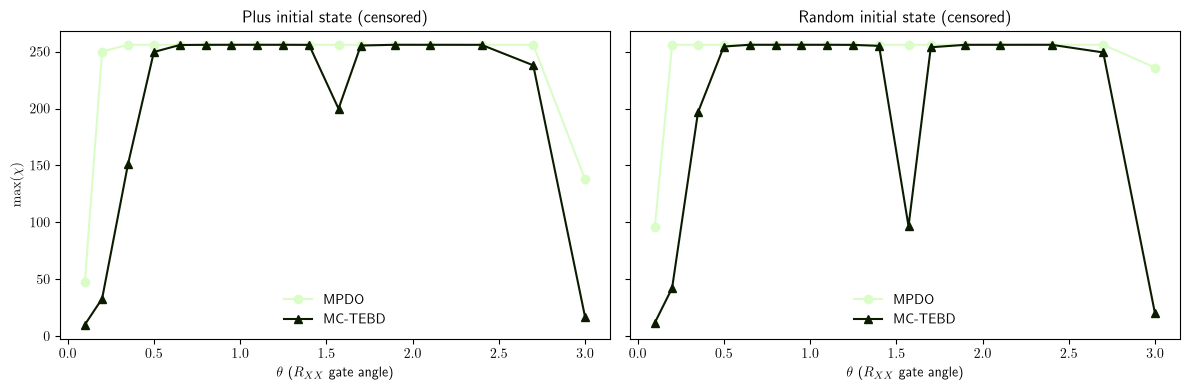

In [12]:
plus = pd.read_csv(f'../results/ckt_theta_n24_plus/theta_sweep_n24_n24plus.csv')
rand = pd.read_csv(f'../results/ckt_theta_n24_rand/theta_sweep_n24_n24rand.csv')
chis = ["chi_mpdo", "chi_traj_mean", "chi_traj_sem"]
s = ["S_op", "S_traj_mean"]
colors = ["#dafdc8", "#0b1b00"]
marker = ["o", "^"]
theta = neel["theta"].to_numpy()

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4),
    sharey=True
)

axes[0].plot(theta, plus["chi_mpdo"], color = colors[0], linestyle = 'solid', marker = marker[0], label = "MPDO")
axes[0].plot(theta, plus["chi_traj_mean"], color = colors[1], linestyle = 'solid', marker = marker[1], label = "MC-TEBD")
axes[0].set_xlabel("$\\theta$ ($R_{XX}$ gate angle)")
axes[0].set_ylabel("$\\max (\\chi)$")
axes[0].set_title("Plus initial state (censored)")
axes[0].legend(frameon = False)

axes[1].plot(theta, rand["chi_mpdo"], color = colors[0], linestyle = 'solid', marker = marker[0], label = "MPDO")
axes[1].plot(theta, rand["chi_traj_mean"], color = colors[1], linestyle = 'solid', marker = marker[1], label = "MC-TEBD")
axes[1].set_xlabel("$\\theta$ ($R_{XX}$ gate angle)")
axes[1].set_title("Random initial state (censored)")
axes[1].legend(frameon = False)

plt.tight_layout()
plt.savefig(f'../results/maximum_bond_dimension_n_24.png', bbox_inches='tight', transparent = True)
plt.show()

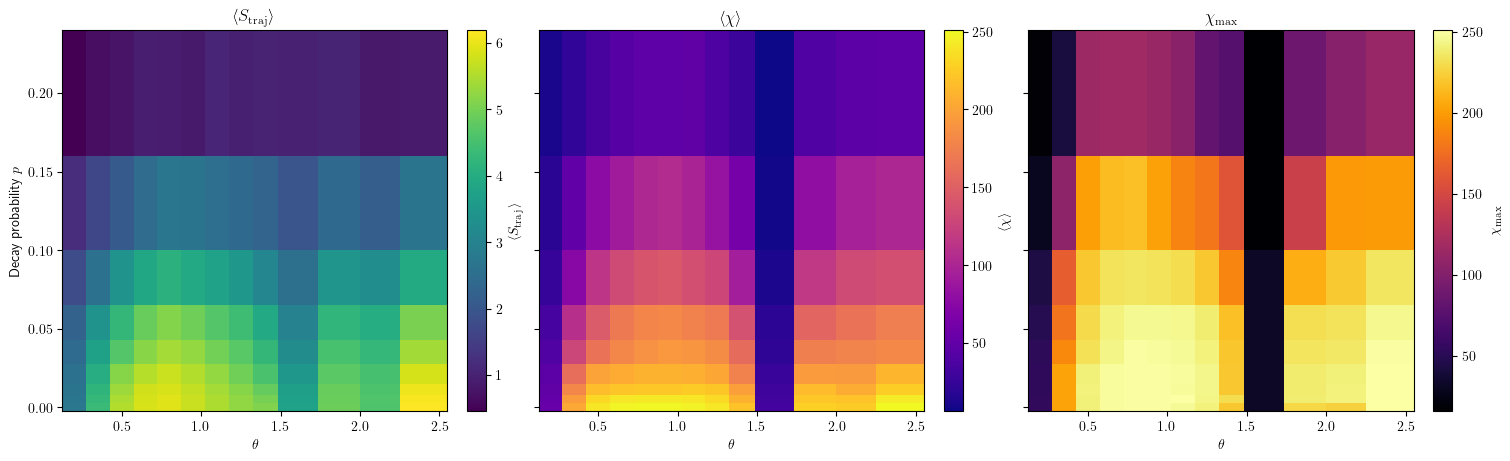

In [9]:

import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv(f'../results/ckt_map/map_n16_m16.csv')

# Quantities to plot: (column name, color map, colorbar label)
quantities = [
    ("S_traj_mean", "viridis", r"$\langle S_{\rm traj}\rangle$"),
    ("chi_mean",    "plasma",  r"$\langle\chi\rangle$"),
    ("chi_max",     "inferno", r"$\chi_{\max}$"),
]

fig, axes = plt.subplots(
    1, 3, figsize=(15, 4.5),
    sharex=True, sharey=True,
    constrained_layout=True
)

for ax, (col, cmap, label) in zip(axes, quantities):

    # Reshape into a 2D grid: rows = p, columns = theta
    grid = df.pivot(
        index="p",
        columns="theta",
        values=col
    ).sort_index().sort_index(axis=1)

    # Plot the heatmap
    mesh = ax.pcolormesh(
        grid.columns,
        grid.index,
        grid.values,
        shading="nearest",
        cmap=cmap
    )

    fig.colorbar(mesh, ax=ax, label=label)

    ax.set_xlabel(r"$\theta$")
    ax.set_title(label)

axes[0].set_ylabel(r"Decay probability $p$")

fig.savefig(f'../results/colormaps_n_16.png', bbox_inches='tight', transparent = True)
plt.show()

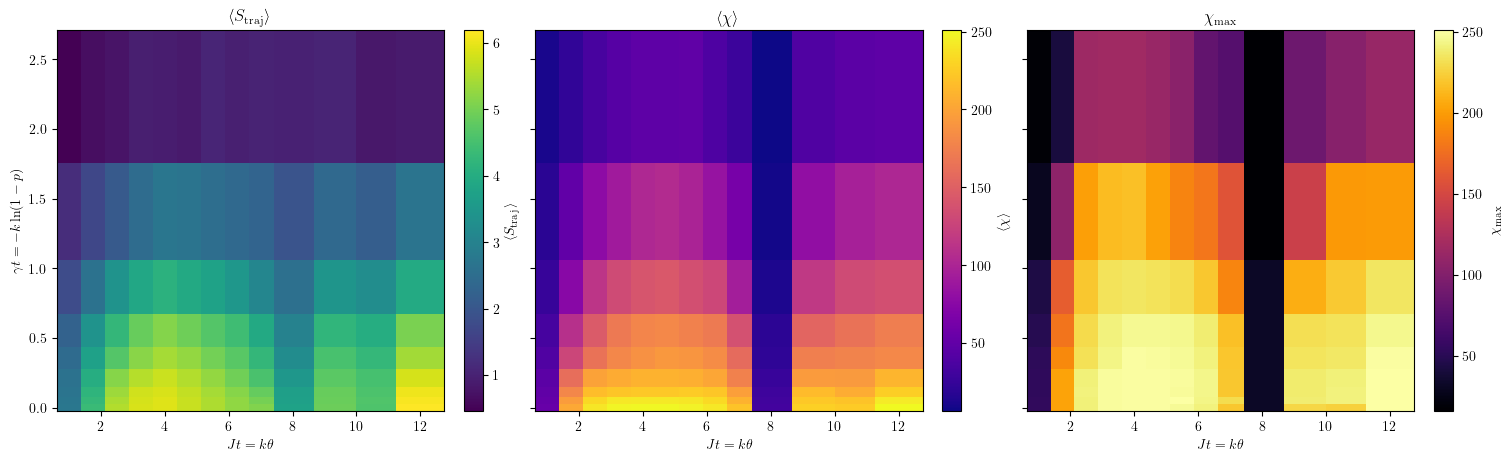

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(f'../results/ckt_map/map_n16_m16.csv')

# Rescale the axes
df["Jt"] = 5 * df["theta"]
df["gamma_t"] = -10 * np.log1p(-df["p"])

quantities = [
    ("S_traj_mean", "viridis", r"$\langle S_{\rm traj}\rangle$"),
    ("chi_mean",    "plasma",  r"$\langle\chi\rangle$"),
    ("chi_max",     "inferno", r"$\chi_{\max}$"),
]

fig, axes = plt.subplots(
    1, 3, figsize=(15, 4.5),
    sharex=True, sharey=True,
    constrained_layout=True
)

for ax, (col, cmap, label) in zip(axes, quantities):

    # Grid using the rescaled coordinates
    grid = df.pivot(
        index="gamma_t",
        columns="Jt",
        values=col
    ).sort_index().sort_index(axis=1)

    mesh = ax.pcolormesh(
        grid.columns,
        grid.index,
        grid.values,
        shading="nearest",
        cmap=cmap
    )

    fig.colorbar(mesh, ax=ax, label=label)

    ax.set_xlabel(r"$Jt = k\theta$")
    ax.set_title(label)

axes[0].set_ylabel(r"$\gamma t = -k\ln(1-p)$")

plt.show()